# Prep notebook 1: Download

Downloads everything needed for the extended accessibility example into a
sibling `prepared/` folder, except employment land use data (covered in
`2_dasymetric_employment.ipynb`)

**Geographical scope:**

This notebook seeds the analysis area from a single geocoded location
(`SEED_LOCATION` below — set to "Bern, Switzerland" by default), buffered
into an *area of interest* (AOI) where accessibility will be computed and
a larger *destination polygon* where data must be available so the
accessibility at the AOI edge isn't clipped.

As a result, the AOI area (~300 km²) is much smaller than the total area (~4,000
km²), caused by the generous 30 km buffer that ensures driving accessibilities
are meaningful throughout the AOI. Our tiered, asymmetric origin-destination
matrices make use of this structure and can be used to limit routing
calculations to only those locations that are actually needed for the
accessibility analysis.

At the default scope (~40 km radius around Bern) we are comfortably inside
Switzerland, so cross-border extrapolation of employment is not yet needed.
Notebook 2 is designed to accommodate it when the scope expands across borders.

**Running the example for a different scope:**

Change `SEED_LOCATION` below to any geocodable place name to retarget the
whole pipeline. The other notebooks read the prepared outputs, so they
need no changes. The main data limitation is employment, which is only
needed if you want to model accessibility to employment opportunities (or
use employment density as a predictor for something, e.g. edge weight
calibration). The second notebook (dasymetric employment mapping) contains
a routine to extrapolate employment information to anywhere on the planet,
learning from Swiss data. The quality of this extrapolation (and of OSM
input data) may vary by location.

Intermediate files may get quite large (several GB each) for country-scale scopes.

**Sources:**

| Data | Source | Notes |
|---|---|---|
| Mode-specific networks | OSM via `osmnx` | `network_type='all'` / `'bike'` / `'drive'` |
| Population | GHSL R2023A, 100 m, Mollweide | Single JRC tile (R4_C19 covers Switzerland) |
| Building footprints | OSM via `osmnx` | Tag-aware: `building=office\|retail\|...` |
| Points of interest | OSM via `osmnx` | Schools, hospitals, supermarkets, etc. |

BFS municipal employment totals (the dasymetric anchor) are fetched in
notebook 2 because they're only used there. Runtime: ~3-5 min on a normal
laptop, mostly the GHSL download.

**Cache convention.** Every download is cached in `prepared/` and skipped
on subsequent runs. If you change something upstream of a cached output
(the AOI / dest polygon, `POI_CATEGORIES`, the network filter for a mode,
…), delete the relevant file in `prepared/` and re-run — there's no
automatic invalidation.

In [7]:
import warnings
import zipfile
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import rasterio
import requests
from rasterio.mask import mask as raster_mask

from aperta import network_processing, osm_helpers

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

# Paths are resolved relative to the directory this notebook is launched from
# (Jupyter convention). Scripts live in `extended/prepare/`; outputs are
# written into `extended/data/prepared/` (gitignored).
PREPARED_DIR = Path('../data/prepared')
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

# === Retargeting knobs ======================================================
# Change these to run the example for a different city. Everything else in
# this notebook (and all downstream notebooks that read PREPARED_DIR) adapts
# automatically.
SEED_LOCATION = 'Bern, Switzerland'    # passed to OSM Nominatim
LOCATION_LABEL = 'Bern'                 # short name for plot titles + prints
CRS_METRIC = 'EPSG:2056'                # Swiss LV95 — use the right metric
                                        # CRS for your country (UTM zone,
                                        # national grid, etc.)
# ============================================================================

# EPSG:4326 only for external APIs that require it (OSMnx polygon queries,
# GHSL tile lookup); reproject back to CRS_METRIC for all spatial ops.
CRS_GEO = 'EPSG:4326'
CRS_MOLLWEIDE = 'ESRI:54009'   # GHSL native projection

## 1. Area of interest and destination polygon

In [8]:
# Fetch the seed polygon via OSM Nominatim. Nominatim's tie-breaking for
# ambiguous names varies — at default the showcase uses 'Bern,
# Switzerland', which resolves to the municipality (admin_level=8,
# ~52 km²) rather than the canton (~5,960 km²). When you change
# `SEED_LOCATION`, eyeball the area below for sanity.
seed_gdf = ox.geocode_to_gdf(SEED_LOCATION)
seed_polygon = seed_gdf.to_crs(CRS_METRIC).geometry.iloc[0]
seed_area_km2 = seed_polygon.area / 1e6
print(f"{LOCATION_LABEL} seed area: {seed_area_km2:.1f} km²")

Bern seed area: 51.6 km²


In [9]:
# AOI = seed + 10 km, smoothed. The buffer rounds the outer boundary; the
# simplify pass drops sub-200 m features that survive the buffer. Result is
# a clean polygon with O(50) vertices.
AOI_BUFFER_M = 10_000
SMOOTH_TOLERANCE_M = 200

aoi_polygon = seed_polygon.buffer(AOI_BUFFER_M).simplify(SMOOTH_TOLERANCE_M)
print(f"AOI area:                {aoi_polygon.area / 1e6:.1f} km²")

# Destination polygon = AOI + 30 km. This is what we fetch raw data for.
DEST_BUFFER_M = 30_000
dest_polygon = aoi_polygon.buffer(DEST_BUFFER_M).simplify(SMOOTH_TOLERANCE_M)
print(f"Destination area:        {dest_polygon.area / 1e6:.1f} km²")

AOI area:                750.6 km²
Destination area:        6562.2 km²


In [10]:
# Save both polygons; notebooks 2, 3, and the main analysis read them in.
gpd.GeoDataFrame(
    {'name': ['aoi']}, geometry=[aoi_polygon], crs=CRS_METRIC,
).to_file(PREPARED_DIR / 'aoi_polygon.gpkg', driver='GPKG')
gpd.GeoDataFrame(
    {'name': ['dest']}, geometry=[dest_polygon], crs=CRS_METRIC,
).to_file(PREPARED_DIR / 'dest_polygon.gpkg', driver='GPKG')

Quick visualisation of the three nested buffer polygons.

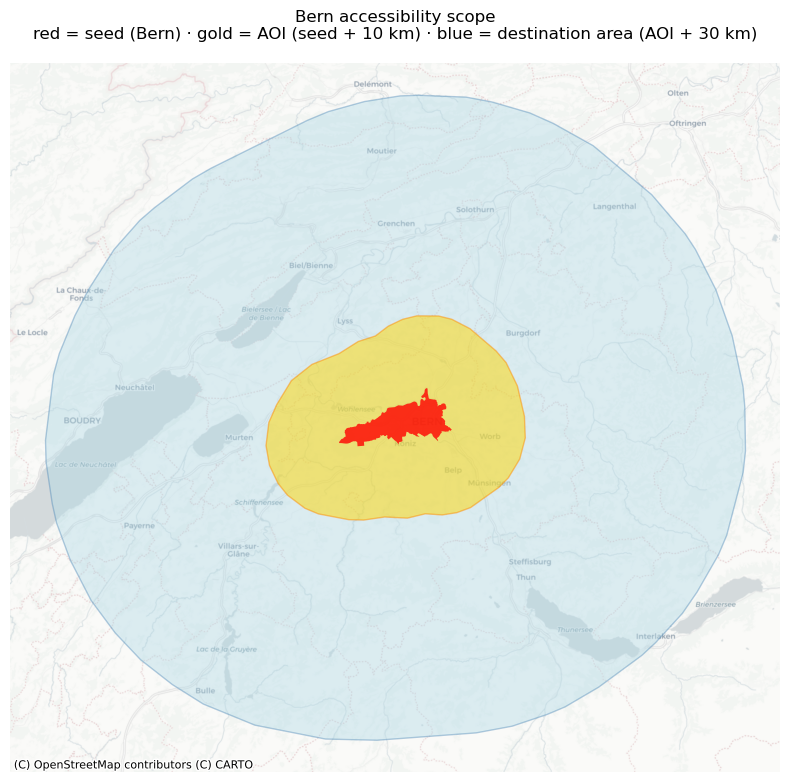

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
gpd.GeoSeries([dest_polygon], crs=CRS_METRIC).plot(
    ax=ax, color='lightblue', alpha=0.4, edgecolor='steelblue', linewidth=1.0,
)
gpd.GeoSeries([aoi_polygon], crs=CRS_METRIC).plot(
    ax=ax, color='gold', alpha=0.5, edgecolor='darkorange', linewidth=1.0,
)
gpd.GeoSeries([seed_polygon], crs=CRS_METRIC).plot(
    ax=ax, color='red', alpha=0.8,
)
# Carto Positron — a neutral grey/white basemap that doesn't compete with
# the overlay colours. `r='@2x'` requests retina tiles (sharper on HiDPI
# displays). `crs=` lets contextily pull tiles in EPSG:3857 and reproject
# them to match our metric-CRS axes — no need to reproject the overlays.
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron(r='@2x'),
    crs=CRS_METRIC,
)
ax.set_title(
    f'{LOCATION_LABEL} accessibility scope\n'
    f'red = seed ({LOCATION_LABEL}) | '
    f'gold = AOI (seed + {AOI_BUFFER_M // 1000:.0f} km) | '
    f'blue = destination area (AOI + {DEST_BUFFER_M // 1000:.0f} km)'
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2. OSM networks (walk + bike + drive)

Three networks, one per mode. `osm_helpers.fetch_network` wraps the
`graph_from_polygon` + `project_graph` boilerplate — takes the polygon
in our metric CRS and returns a graph already in that CRS.

Network-type notes:

- **`'walk'`**: walkable streets and paths. Set to 'all' because 'walk' networks
  can currently exclude important pedestrian-ony paths next to motorways if they
  are connected to the rest of the network via those motorways in the graph
  topology. It's a trade-off: 'all' risks overestimating pedestrian
  accessibility, 'walk' risks the introduction of pedestrian network islands
  that don't exist in the real world.
- **`'bike'`**: cycle-accessible network. Includes pedestrian paths
  (where cycling is typically allowed) plus residential / cycleway
  infrastructure. Excludes motorways.
- **`'drive'`**: car-accessible road network. Smallest of the three —
  excludes pedestrian paths, cycleways, service roads.

In [12]:
# Each network is saved in two forms:
#   - `<name>_raw.graphml`  — exactly what OSMnx returned (after simplify=True).
#   - `<name>.graphml`      — after `consolidate_intersections` (the primary
#                              output read by downstream notebooks).
# The raw form is kept so the before/after comparison plot at the end of this
# section is reproducible on re-runs (cached cleanly), and so future
# experiments with different consolidation tolerances don't require re-fetch.
#
# `(mode_label, osm_network_type, name_stem)`. We fetch the walking
# network with OSMnx `network_type='all'` (not `'walk'`) so trunk roads
# stay in — pedestrians legitimately use sidewalks along these, and
# `'walk'` over-filters in urban areas. See the walkthrough notebook
# for the full rationale. The dict key stays `'walk'` (semantic).
MODES = [
    ('walk',  'all',   'walk_graph'),
    ('bike',  'bike',  'bike_graph'),
    ('drive', 'drive', 'car_graph'),
]
raw_graphs: dict[str, 'ox.graph'] = {}

for mode, osm_type, name_stem in MODES:
    raw_path = PREPARED_DIR / f'{name_stem}_raw.graphml'
    if raw_path.exists():
        print(f"{mode} raw network cached at {raw_path} — loading.")
        raw_graphs[mode] = ox.load_graphml(raw_path)
    else:
        print(f"Fetching {mode} network (OSMnx network_type='{osm_type}')...")
        raw_graphs[mode] = osm_helpers.fetch_network(
            polygon=dest_polygon, polygon_crs=CRS_METRIC,
            network_type=osm_type, target_crs=CRS_METRIC,
            simplify=True,
        )
        ox.save_graphml(raw_graphs[mode], raw_path)
    g = raw_graphs[mode]
    print(f"  {mode:5s}: {g.number_of_nodes():,} nodes, "
          f"{g.number_of_edges():,} edges")

Fetching walk network (OSMnx network_type='all')...
  walk : 413,682 nodes, 1,067,064 edges
Fetching bike network (OSMnx network_type='bike')...
  bike : 326,318 nodes, 796,467 edges
Fetching drive network (OSMnx network_type='drive')...
  drive: 59,853 nodes, 141,359 edges


### Intersection consolidation

Raw OSM graphs split each intersection into several closely-spaced
nodes — one per approach lane / signalised arm / pedestrian crossing
point — which inflates node counts and makes intersection-based edge
weights (signals, ≥3-way / ≥4-way crossings) misleading. `network_
processing.consolidate_intersections` wraps `osmnx.consolidate_
intersections` with one important addition: traffic-signal / stop /
yield nodes (typically sitting a few metres off the geometric
intersection centre) and `junction=roundabout` edges are captured
*before* consolidation, then re-attached to the nearest surviving
consolidated node within `obstacle_buffer` metres. Without this
step OSMnx silently drops most signal flags.

Obstacle source: extracted once from the raw car graph and reused
across all three networks. Signals on car-only ways (e.g. trunk
roads excluded from the walk-network filter) would otherwise never
enter the walk graph's node set and be silently dropped from
walk-graph consolidation — using the car graph as the canonical
source guarantees full coverage for every mode.

Per-mode tolerance: walk and bike use a smaller value (10 m) to
preserve pedestrian crossings as distinct nodes; cars use 15 m to
merge multi-arm signalised intersections into a single point.

In [13]:
CONSOLIDATION_TOLERANCE = {'walk': 10.0, 'bike': 10.0, 'drive': 15.0}
OBSTACLE_NODE_TAGS = {
    'traffic_signal': ('highway', 'traffic_signals'),
    'stop':           ('highway', 'stop'),
    'yield':          ('highway', 'give_way'),
}

# Extract obstacles ONCE from the raw car graph (the most signal-
# complete source) and reuse for all three consolidations. Otherwise
# obstacles tagged on car-only ways — e.g. signals on trunk roads —
# never enter the walk graph's node set in the first place and get
# silently dropped during walk-graph consolidation. Roundabouts are
# road features only, so the car graph is the authoritative source.
shared_obstacles, shared_roundabouts = (
    network_processing.extract_obstacle_locations(
        raw_graphs['drive'],
        obstacle_node_tags=OBSTACLE_NODE_TAGS,
        detect_roundabouts=True,
    ))
print(f"Obstacles extracted from raw car graph: "
      + ', '.join(f'{k}={len(v)}' for k, v in shared_obstacles.items())
      + f", roundabouts={len(shared_roundabouts)}")

graphs: dict[str, 'ox.graph'] = {}
for mode, osm_type, name_stem in MODES:
    cons_path = PREPARED_DIR / f'{name_stem}.graphml'
    if cons_path.exists():
        print(f"{mode} consolidated network cached at {cons_path} — loading.")
        # `load_consolidated_graphml` (not `ox.load_graphml`) so aperta's
        # custom node + edge attrs (`is_*` flags, `lanes_per_direction`)
        # round-trip with the right dtypes — otherwise they come back as
        # strings and silently break arithmetic.
        graphs[mode] = network_processing.load_consolidated_graphml(cons_path)
    else:
        print(f"Consolidating {mode} (tol={CONSOLIDATION_TOLERANCE[mode]} m)...")
        graphs[mode] = network_processing.consolidate_intersections(
            raw_graphs[mode],
            tolerance=CONSOLIDATION_TOLERANCE[mode],
            obstacle_buffer=30.0,
            obstacle_locations=shared_obstacles,
            roundabout_locations=shared_roundabouts,
            detect_roundabouts=True,
        )
        ox.save_graphml(graphs[mode], cons_path)
    raw = raw_graphs[mode]
    cons = graphs[mode]
    pct = 100 * (1 - cons.number_of_nodes() / raw.number_of_nodes())
    n_sig = sum(int(d.get('is_traffic_signal', 0)) for _, d in cons.nodes(data=True))
    n_rb  = sum(int(d.get('is_roundabout',     0)) for _, d in cons.nodes(data=True))
    print(f"  {mode:5s}: {raw.number_of_nodes():,} → {cons.number_of_nodes():,} nodes "
          f"({pct:.0f}% reduction); signals={n_sig:,}, roundabouts={n_rb:,}")

# Undirect walk and bike graphs so one-way street rules (a directed-graph
# default from OSMnx's MultiDiGraph) don't silently produce zero-accessibility
# outliers at one-way termini — pedestrians and cyclists typically contraflow.
# For fully accurate bicycle evaluation, directedness should be preserved, but
# cells should be snapped in a way that they cannot get snapped to termini.
# A corresponding feature is planned.
for mode in ('walk', 'bike'):
    graphs[mode] = graphs[mode].to_undirected()

walk_graph = graphs['walk']
bike_graph = graphs['bike']
car_graph = graphs['drive']

Obstacles extracted from raw car graph: traffic_signal=100, stop=1, yield=5, roundabouts=3538
Consolidating walk (tol=10.0 m)...
  walk : 413,682 → 204,450 nodes (51% reduction); signals=95, roundabouts=811
Consolidating bike (tol=10.0 m)...
  bike : 326,318 → 182,320 nodes (44% reduction); signals=93, roundabouts=826
Consolidating drive (tol=15.0 m)...
  drive: 59,853 → 33,860 nodes (43% reduction); signals=97, roundabouts=769


### Per-edge speeds for the car graph (OSM `maxspeed` + fallback)

Reads each car edge's OSM `maxspeed` tag and falls back to a per-
highway-class default for the (many) edges without one. The resulting
`speed_kph` attribute on every car edge is consumed by the edge-time
formula in `accessibility.ipynb` / `calibrate_edge_weights.ipynb` /
`traffic_flows.ipynb`. Idempotent — safe to re-run on a cached graphml.

Walk and bike use a constant per-mode speed set inline downstream,
so no per-edge speed is needed for them.

In [14]:
HWY_SPEEDS = {
    'motorway': 120, 'motorway_link': 80,
    'trunk': 100,    'trunk_link': 60,
    'primary': 80,   'primary_link': 50,
    'secondary': 50, 'secondary_link': 40,
    'tertiary': 50,  'tertiary_link': 40,
    'unclassified': 50,
    'residential': 30,
    'living_street': 20,
    'service': 30,
    'road': 30,
    'busway': 30,
}
ox.add_edge_speeds(car_graph, hwy_speeds=HWY_SPEEDS)
ox.save_graphml(car_graph, PREPARED_DIR / 'car_graph.graphml')
car_speeds = np.array([float(d['speed_kph'])
                       for _, _, d in car_graph.edges(data=True)])
print(f"Car edge speeds applied. Median {np.median(car_speeds):.0f} km/h, "
      f"range {car_speeds.min():.0f}–{car_speeds.max():.0f} km/h.")

Car edge speeds applied. Median 30 km/h, range 10–120 km/h.


## 3. Population — GHSL R2023A (100 m)

GHS-POP is the EU JRC's flagship gridded-population product (also widely
cited by UN and World Bank work). Used here for two reasons:

1. **It's global.** STATPOP would give finer Swiss data but isn't fully
   public anymore, and (load-bearing for the cross-border-buffer design)
   it stops at the Swiss border. GHSL handles cross-border naturally —
   important once we extend the scope.
2. **It's at 100 m, matching typical aperta cell sizes.**

GHSL data live on the JRC's open data FTP, distributed as ~10° × 10° tiles
in Mollweide projection (ESRI:54009). Switzerland sits in tile **R4_C19**.
The download is ~50-100 MB; cached on first run.

In [15]:
GHSL_TILE_ROW = 'R4'
GHSL_TILE_COL = 'C19'

GHSL_TILE_NAME = (
    f'GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0_{GHSL_TILE_ROW}_{GHSL_TILE_COL}'
)
GHSL_TILE_URL = (
    'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/'
    'GHS_POP_GLOBE_R2023A/GHS_POP_E2020_GLOBE_R2023A_54009_100/V1-0/tiles/'
    f'{GHSL_TILE_NAME}.zip'
)
GHSL_ZIP_PATH = PREPARED_DIR / f'{GHSL_TILE_NAME}.zip'
GHSL_TIF_PATH = PREPARED_DIR / f'{GHSL_TILE_NAME}.tif'
GHSL_POP_CLIPPED_PATH = PREPARED_DIR / 'population_ghsl_100m.tif'

In [16]:
# Download (cached).
if not GHSL_ZIP_PATH.exists() and not GHSL_TIF_PATH.exists():
    print(f"Downloading GHSL tile {GHSL_TILE_ROW}_{GHSL_TILE_COL} (~80 MB)...")
    response = requests.get(GHSL_TILE_URL, stream=True, timeout=60)
    response.raise_for_status()
    with open(GHSL_ZIP_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"  Saved to {GHSL_ZIP_PATH}")

# Unzip — extract ONLY the .tif (the zip also bundles a PDF data-package
# and metadata XLSX, which are documentation rather than data).
if not GHSL_TIF_PATH.exists():
    print("Unzipping (.tif only)...")
    with zipfile.ZipFile(GHSL_ZIP_PATH, 'r') as z:
        for member in z.namelist():
            if member.endswith('.tif'):
                z.extract(member, PREPARED_DIR)
    # Cleanup: drop the .zip once the .tif is extracted.
    GHSL_ZIP_PATH.unlink(missing_ok=True)

  Saved to ../data/prepared/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0_R4_C19.zip
Unzipping (.tif only)...


In [17]:
# Clip to the destination polygon (reprojected to Mollweide) and save.
if not GHSL_POP_CLIPPED_PATH.exists():
    dest_polygon_mollweide = gpd.GeoSeries(
        [dest_polygon], crs=CRS_METRIC,
    ).to_crs(CRS_MOLLWEIDE).iloc[0]

    with rasterio.open(GHSL_TIF_PATH) as src:
        pop_clipped, pop_transform = raster_mask(
            src, [dest_polygon_mollweide.__geo_interface__], crop=True,
        )
        pop_meta = src.meta.copy()
    pop_meta.update({
        'driver': 'GTiff',
        'height': pop_clipped.shape[1],
        'width': pop_clipped.shape[2],
        'transform': pop_transform,
        'compress': 'lzw',
    })
    with rasterio.open(GHSL_POP_CLIPPED_PATH, 'w', **pop_meta) as dst:
        dst.write(pop_clipped)

In [18]:
# Quick sanity check: at the default scope (~40 km radius, ≈4,000 km²
# around a mid-sized European city) total population should land in the
# ~1-1.3 M range. Adjust the assert bounds if your seed location is in
# a much larger or much smaller agglomeration.
with rasterio.open(GHSL_POP_CLIPPED_PATH) as src:
    pop = src.read(1)
total_pop = float(pop[pop > 0].sum())
print(f"GHSL clipped: {pop.shape[0]} × {pop.shape[1]} pixels; "
      f"total population ≈ {total_pop:,.0f}")
assert 200_000 < total_pop < 2_000_000, (
    f"Total population {total_pop:,.0f} is out of the expected range. "
    f"Either the GHSL tile doesn't cover your seed location (check the "
    f"tile row/column: {GHSL_TILE_ROW}_{GHSL_TILE_COL}), or your scope "
    f"is much larger / smaller than the default Bern showcase."
)

GHSL clipped: 846 × 990 pixels; total population ≈ 1,551,024


## 4. OSM building footprints

All buildings within the destination polygon, with their `building=*` tag
preserved. The tag drives the dasymetric employment step in notebook 2 —
different building types (office, retail, industrial, residential, …) get
different workers-per-m² coefficients.

In [19]:
BUILDINGS_PATH = PREPARED_DIR / 'buildings.gpkg'

if BUILDINGS_PATH.exists():
    print(f"Buildings already at {BUILDINGS_PATH} — loading from disk.")
    buildings = gpd.read_file(BUILDINGS_PATH)
else:
    print("Fetching buildings from OSM (this can take a minute)...")
    dest_polygon_4326 = gpd.GeoSeries(
        [dest_polygon], crs=CRS_METRIC,
    ).to_crs(CRS_GEO).iloc[0]
    raw = ox.features_from_polygon(dest_polygon_4326, tags={'building': True})
    # Keep only polygon footprints. Multi-polygons are kept (some large complexes
    # are tagged as relations). Point-tagged buildings are dropped.
    raw = raw[raw.geometry.type.isin(['Polygon', 'MultiPolygon'])]
    buildings = raw[['geometry', 'building']].to_crs(CRS_METRIC).copy()
    buildings['area_m2'] = buildings.geometry.area
    # Filter out tiny outliers (footprint cells, mapping artefacts).
    buildings = buildings[buildings['area_m2'] >= 10.0].reset_index(drop=True)
    buildings.to_file(BUILDINGS_PATH, driver='GPKG')

print(f"{len(buildings):,} buildings "
      f"(total footprint area: {buildings['area_m2'].sum()/1e6:.1f} km²)")
print("Top 10 building tags:")
print(buildings['building'].value_counts().head(10).to_string())

Fetching buildings from OSM (this can take a minute)...
554,135 buildings (total footprint area: 110.9 km²)
Top 10 building tags:
building
yes            272995
residential    124149
garage          27449
barn            21309
house           20869
farm            19507
apartments      18938
shed             8889
roof             7839
detached         4645


## 5. POIs (selected amenities and leisure locations)

These are used directly as accessibility destinations (one point = one
opportunity, optionally weighted). OSM tags are assumed to be the ground
truth for sector-specific locations. They are not subject to dasymetric
mapping - dasymmetric mapping is reserved for the aggregate "all jobs" / 
tertiary employment layer (notebook 2).

**Category map.** Each user-defined category bundles one or more
`'key:value'` OSM tag pairs, each with an optional weight (default 1.0).
Weights let you down-weight loose substitutes (a `convenience` shop counts
as 0.5 of a `supermarket` for the `groceries` category) — useful for
weighted accessibility metrics. Categories with weight = 1 across the
board are simple counts.

In this example, we consider three categories of POIs. In a full accessibility
analysis for all common trip purposes, you may want to add to or change the list.

In [20]:
POI_CATEGORIES = {
    'poi_errands_groceries': [
        ('shop:supermarket', 1.5),
        ('shop:convenience', 0.5),
        ('shop:bakery',      0.5),
        ('shop:farm',        0.5),
    ],
    'poi_education_children': [
        ('amenity:kindergarten', 1.0),
        ('amenity:school', 1.0),
    ],
    'poi_leisure_hiking': [
        ('information:guidepost',   1.0),
        ('highway:trailhead',       1.0),
    ],
}

POIS_PATH = PREPARED_DIR / 'pois.gpkg'

if POIS_PATH.exists():
    print(f"POIs already at {POIS_PATH} — loading from disk.")
    pois = gpd.read_file(POIS_PATH)
else:
    print("Fetching POIs from OSM...")
    pois = osm_helpers.fetch_pois(
        polygon=dest_polygon, polygon_crs=CRS_METRIC,
        category_map=POI_CATEGORIES,
        target_crs=CRS_METRIC,
        use_centroid=True,
    )
    pois = pois.reset_index(drop=True)
    pois.to_file(POIS_PATH, driver='GPKG')

print(f"{len(pois):,} POIs matched at least one category.")
print("Per-category counts (#) and total weights (Σw):")
for cat in POI_CATEGORIES:
    n = int(pois[cat].sum())
    w = float(pois[f'{cat}_weight'].sum())
    print(f"  {cat:30s}  #{n:>5,}  Σw={w:,.1f}")

Fetching POIs from OSM...
11,219 POIs matched at least one category.
Per-category counts (#) and total weights (Σw):
  poi_errands_groceries           #2,123  Σw=1,829.5
  poi_education_children          #1,506  Σw=1,506.0
  poi_leisure_hiking              #7,590  Σw=7,590.0


## Summary

In [21]:
print(f"\nPrepared files in {PREPARED_DIR.resolve()}:\n")
for p in sorted(PREPARED_DIR.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        size_str = f"{sz/1e6:.1f} MB" if sz > 1e6 else f"{sz/1e3:.1f} KB"
        print(f"  {p.name:50s} {size_str:>10s}")


Prepared files in /Users/mmiotti/Library/CloudStorage/OneDrive-ETHZurich/Work/01 Aperta/aperta/examples/extended/data/prepared:

  GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif    95.3 MB
  aoi_polygon.gpkg                                      98.3 KB
  bike_graph.graphml                                   489.5 MB
  bike_graph_raw.graphml                               541.8 MB
  buildings.gpkg                                       151.4 MB
  car_graph.graphml                                    109.5 MB
  car_graph_raw.graphml                                127.2 MB
  dest_polygon.gpkg                                     98.3 KB
  pois.gpkg                                              8.2 MB
  population_ghsl_100m.tif                               1.1 MB
  walk_graph.graphml                                   582.7 MB
  walk_graph_raw.graphml                               665.8 MB


## Appendix: visual check — before / after consolidation

Optional diagnostic. 4 × 4 km zoom centred on the AOI centroid, with
two columns (car / walk) and two rows (raw / consolidated). Obstacle
markers in the raw plots are the shared set extracted once from the
raw car graph (same in both raw panels — same source); in the
consolidated plots they're the per-node `is_*` flags after spatial
reattachment.

This is what `network_processing.consolidate_intersections` actually
does — visually. Skippable if you trust the consolidation step.

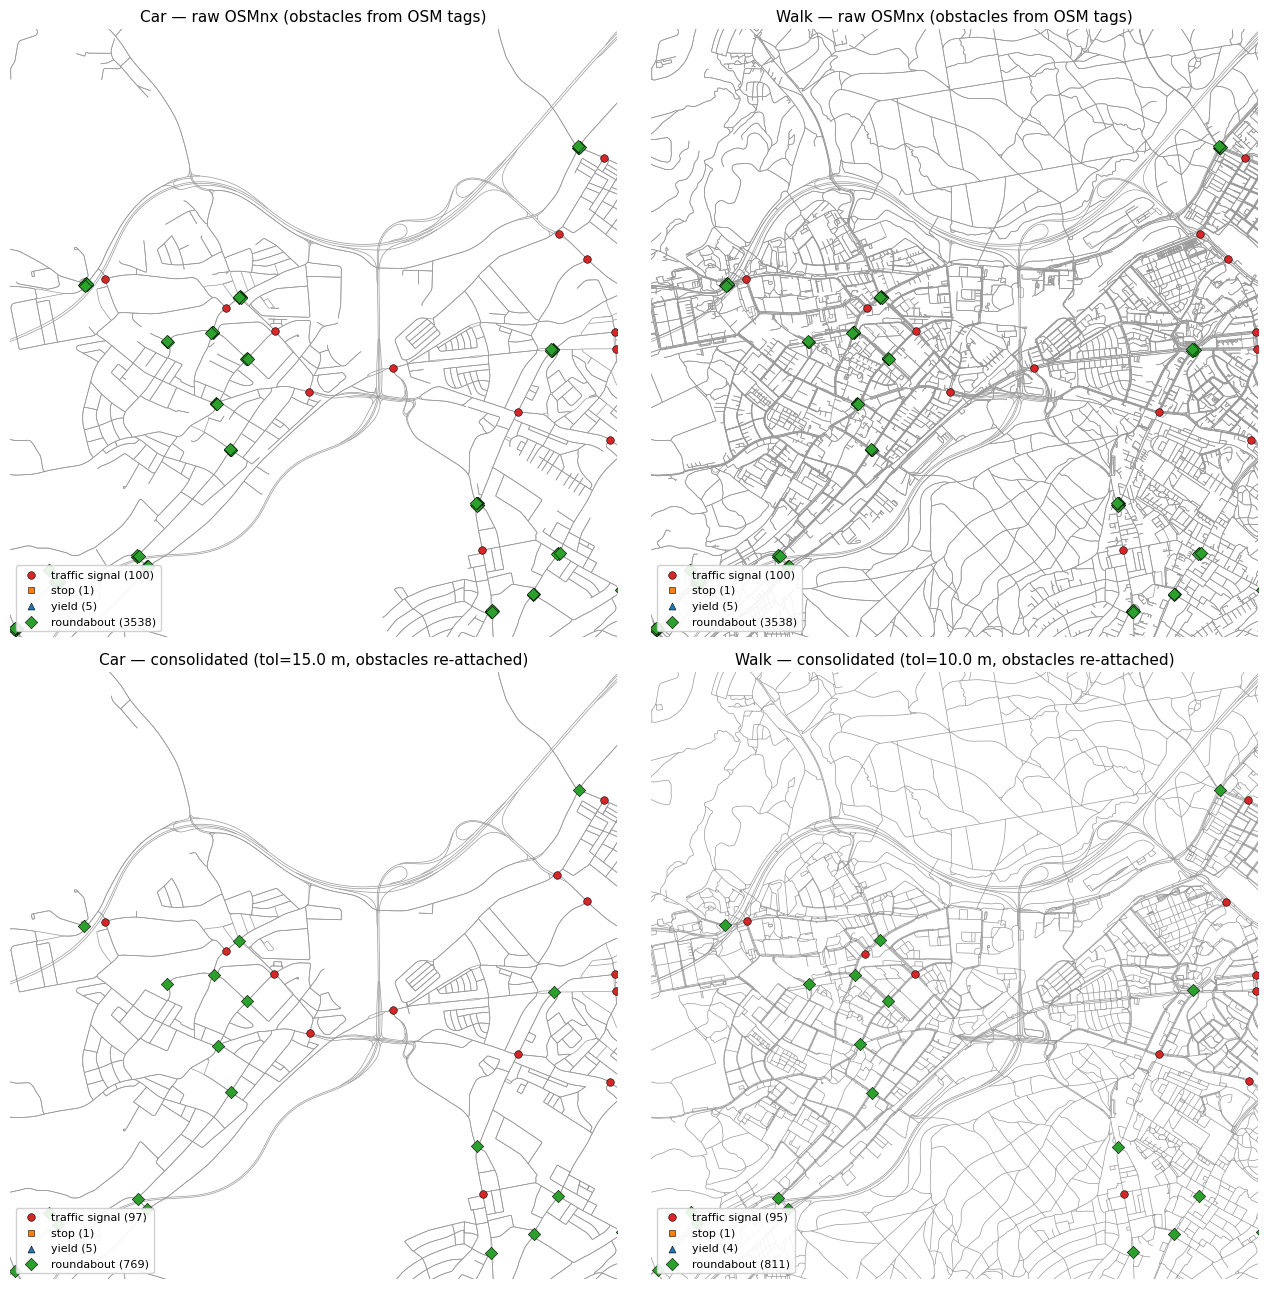

In [22]:
_ZOOM_CX, _ZOOM_CY = aoi_polygon.centroid.x, aoi_polygon.centroid.y
_ZOOM_HALF = 2_000

_OBSTACLE_STYLE = {
    'traffic_signal': {'color': '#d62728', 'marker': 'o', 'size': 30, 'label': 'traffic signal'},
    'stop':           {'color': '#ff7f0e', 'marker': 's', 'size': 25, 'label': 'stop'},
    'yield':          {'color': '#1f77b4', 'marker': '^', 'size': 25, 'label': 'yield'},
    'roundabout':     {'color': '#2ca02c', 'marker': 'D', 'size': 40, 'label': 'roundabout'},
}

def _raw_obstacles(_g) -> dict[str, list[tuple[float, float]]]:
    """The shared obstacle set (extracted once from the raw car graph,
    reused for every consolidation). Same dots appear in both raw panels."""
    return {**shared_obstacles, 'roundabout': shared_roundabouts}

def _consolidated_obstacles(g: 'ox.graph') -> dict[str, list[tuple[float, float]]]:
    """Pull obstacle locations from per-node `is_*` flags on the consolidated graph."""
    out = {name: [] for name in _OBSTACLE_STYLE}
    for _, d in g.nodes(data=True):
        for obs_name in _OBSTACLE_STYLE:
            if d.get(f'is_{obs_name}', 0) == 1.0:
                out[obs_name].append((d['x'], d['y']))
    return out

def _plot_panel(ax, graph, obstacles, title):
    ox.plot_graph(graph, ax=ax, node_size=0, edge_color='#999',
                  edge_linewidth=0.5, bgcolor='white', show=False, close=False)
    for obs_name, style in _OBSTACLE_STYLE.items():
        pts = obstacles.get(obs_name, [])
        if not pts:
            continue
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, s=style['size'], c=style['color'],
                   marker=style['marker'], edgecolors='black', linewidths=0.4,
                   label=f"{style['label']} ({len(pts)})", zorder=5)
    ax.set_xlim(_ZOOM_CX - _ZOOM_HALF, _ZOOM_CX + _ZOOM_HALF)
    ax.set_ylim(_ZOOM_CY - _ZOOM_HALF, _ZOOM_CY + _ZOOM_HALF)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
_plot_panel(axes[0, 0], raw_graphs['drive'], _raw_obstacles(raw_graphs['drive']),
            'Car — raw OSMnx (obstacles from OSM tags)')
_plot_panel(axes[0, 1], raw_graphs['walk'], _raw_obstacles(raw_graphs['walk']),
            'Walk — raw OSMnx (obstacles from OSM tags)')
_plot_panel(axes[1, 0], graphs['drive'], _consolidated_obstacles(graphs['drive']),
            f"Car — consolidated (tol={CONSOLIDATION_TOLERANCE['drive']} m, "
            'obstacles re-attached)')
_plot_panel(axes[1, 1], graphs['walk'], _consolidated_obstacles(graphs['walk']),
            f"Walk — consolidated (tol={CONSOLIDATION_TOLERANCE['walk']} m, "
            'obstacles re-attached)')
plt.tight_layout()
plt.show()